# 人工智能基础课程：上机练习

### 第六节-练习 1：K-Means 聚类练习

*作者：陈开*

**学习目标：**
- 通过Python实现KMeans聚类算法
- 探索不同参数下，KMeans的聚类效果

In [2]:
# 导入必要的库
#!pip install ipywidgets
#!pip install matplotlib
#!pip install scikit-learn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import ipywidgets
from ipywidgets import interact


## 生成数据集

为了演示K-means，我们将使用`make_blobs`函数创建一个简单的合成数据集，其中包含若干2维数据点。



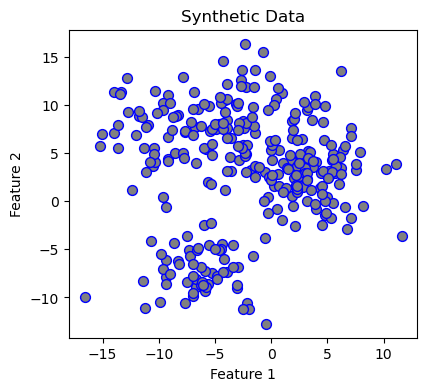

In [3]:

# 创建演示数据集，其中包含 5 个簇， 300 个样本点
X, y = make_blobs(n_samples=300, n_features=2, centers=5, cluster_std=3.0, random_state=42)
    
# 可视化数据点
plt.figure(figsize=(4.5, 4))
plt.scatter(X[:, 0], X[:, 1], s=50, c='gray', marker='o', edgecolor='blue')
plt.title('Synthetic Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()


# 实现K-means算法

我们设定k=3，然后使用K-means算法对数据集进行聚类。


In [4]:
# 查看数组尺寸
X.shape

(300, 2)

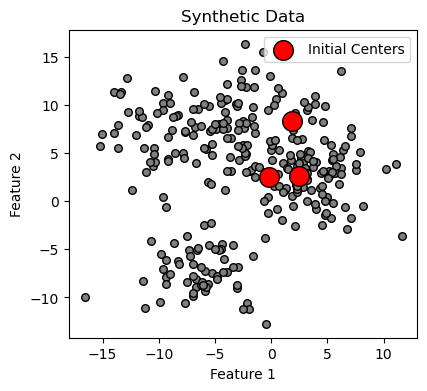

In [5]:
# 随机选取三个样本点作为初始中心点
init_centers = X[np.random.choice(range(X.shape[0]), 3)]

# 画出初始中心点 与 数据点
plt.figure(figsize=(4.5, 4))
plt.scatter(X[:, 0], X[:, 1], s=30, c='gray', marker='o', edgecolor='black')
plt.scatter(init_centers[:, 0], init_centers[:, 1], s=200, c='red', marker='o', edgecolor='black', label='Initial Centers')
plt.title('Synthetic Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

In [6]:
# 根据初始化的中心点，计算每个样本点到中心点的距离
distances = np.sqrt(((X - init_centers[:, np.newaxis])**2).sum(axis=2))

# 找到每个样本点距离最近的中心点
closest_center = np.argmin(distances, axis=0)


In [7]:
distances.shape

(3, 300)

In [8]:
closest_center

array([0, 0, 1, 2, 0, 1, 1, 1, 1, 2, 2, 1, 2, 0, 2, 1, 2, 2, 1, 1, 0, 0,
       1, 1, 2, 1, 1, 2, 2, 1, 0, 2, 1, 0, 1, 2, 2, 2, 0, 2, 0, 2, 1, 0,
       2, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 2, 0, 1, 2,
       1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 2, 0, 1, 1, 0, 2, 0, 1, 0, 2,
       1, 2, 2, 2, 0, 0, 0, 0, 2, 1, 1, 1, 1, 1, 2, 1, 2, 0, 1, 2, 0, 2,
       0, 0, 2, 2, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 2, 1, 1, 0, 2, 1,
       1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 2, 0, 1, 2, 1, 2, 1, 0, 1, 1, 2,
       0, 0, 1, 0, 0, 2, 1, 1, 1, 2, 0, 1, 1, 2, 2, 2, 1, 0, 2, 0, 0, 2,
       0, 2, 1, 1, 1, 1, 2, 1, 1, 0, 0, 1, 1, 2, 2, 1, 1, 1, 1, 0, 1, 1,
       0, 2, 1, 1, 1, 2, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 0, 2, 1, 1, 2, 1, 2, 1, 0, 1, 0, 2, 1, 1, 2, 2, 2, 2, 0, 0, 2,
       1, 1, 1, 1, 0, 0, 1, 1, 2, 1, 1, 1, 1, 2, 1, 2, 1, 2, 1, 0, 2, 2,
       2, 0, 2, 2, 1, 2, 1, 1, 1, 1, 0, 1, 2, 0, 1, 2, 0, 0, 0, 2, 2, 1,
       1, 1, 2, 2, 1, 2, 1, 1, 0, 1, 1, 0, 0, 0])

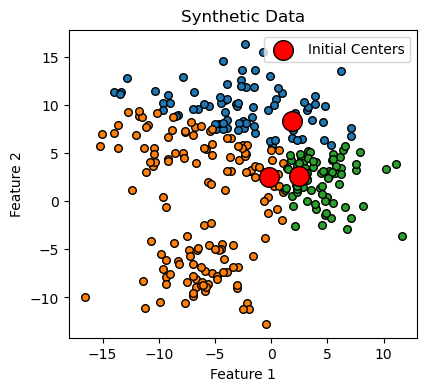

In [9]:
# 根据最近的中心点，对数据点进行分类并染色
plt.figure(figsize=(4.5, 4))
for i in range(3):
    plt.scatter(X[closest_center == i, 0], X[closest_center == i, 1], s=30, marker='o', edgecolor='black')
plt.scatter(init_centers[:, 0], init_centers[:, 1], s=200, c='red', marker='o', edgecolor='black', label='Initial Centers')
plt.title('Synthetic Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

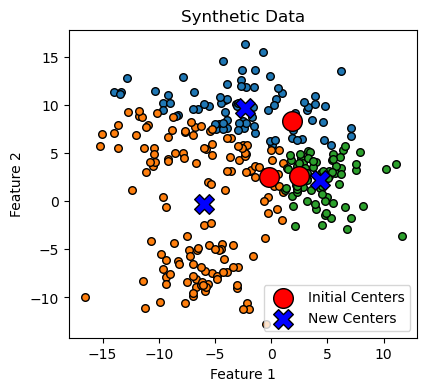

In [10]:
# 根据当前分类，重新计算中心点
new_centers = np.array([X[closest_center == i].mean(axis=0) for i in range(3)])

# 画出新的中心点 与 数据点
plt.figure(figsize=(4.5, 4))
for i in range(3):
    plt.scatter(X[closest_center == i, 0], X[closest_center == i, 1], s=30, marker='o', edgecolor='black')
plt.scatter(init_centers[:, 0], init_centers[:, 1], s=200, c='red', marker='o', edgecolor='black', label='Initial Centers')
plt.scatter(new_centers[:, 0], new_centers[:, 1], s=200, c='blue', marker='X', edgecolor='black', label='New Centers')
plt.title('Synthetic Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

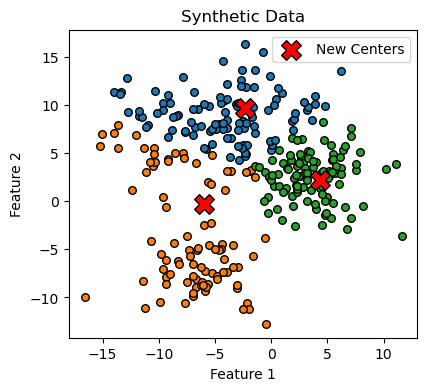

In [11]:
# 根据新的中心点，计算每个样本点到中心点的距离
distances = np.sqrt(((X - new_centers[:, np.newaxis])**2).sum(axis=2))
# 找到每个样本点距离最近的中心点
closest_center = np.argmin(distances, axis=0)

# 根据最近的中心点，对数据点进行分类并染色
plt.figure(figsize=(4.5, 4))
for i in range(3):
    plt.scatter(X[closest_center == i, 0], X[closest_center == i, 1], s=30, marker='o', edgecolor='black')
plt.scatter(new_centers[:, 0], new_centers[:, 1], s=200, c='red', marker='X', edgecolor='black', label='New Centers')
plt.title('Synthetic Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()


In [12]:
# 循环迭代
@interact(
    n=ipywidgets.IntSlider(value=0, min=0, max=10, step=1, description="迭代次数"),
    seed = ipywidgets.IntSlider(value=42, min=0, max=100, step=1, description="随机种子"),
    k = ipywidgets.IntSlider(value=2, min=2, max=10, step=1, description="k")
)
def plot_kmeans(n, seed, k):
    centers = None
    # k = 3
    for i in range(n+1):
        if centers is None:
            # 随机选取三个样本点作为初始中心点
            np.random.seed(seed)
            centers = X[np.random.choice(range(X.shape[0]), k)]
        else:
            # 根据当前分类，重新计算中心点
            centers = np.array([X[closest_center == i].mean(axis=0) for i in range(k)])
        # 根据新的中心点，计算每个样本点到中心点的距离
        distances = np.sqrt(((X - centers[:, np.newaxis])**2).sum(axis=2))
        # 找到每个样本点距离最近的中心点
        closest_center = np.argmin(distances, axis=0)
    # 画出新的中心点 与 数据点
    plt.figure(figsize=(4.5, 4))
    for i in range(k):
        plt.scatter(X[closest_center == i, 0], X[closest_center == i, 1], s=30, marker='o', ec='black')
    plt.scatter(centers[:, 0], centers[:, 1], s=100, c='red', marker='X', ec='black',label='Current Centers')
    plt.title('Synthetic Data')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.show()

interactive(children=(IntSlider(value=0, description='迭代次数', max=10), IntSlider(value=42, description='随机种子'),…

## 使用 sci-kit learn 实现K-means

c:\Users\xuzhi\miniconda3\envs\py3\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


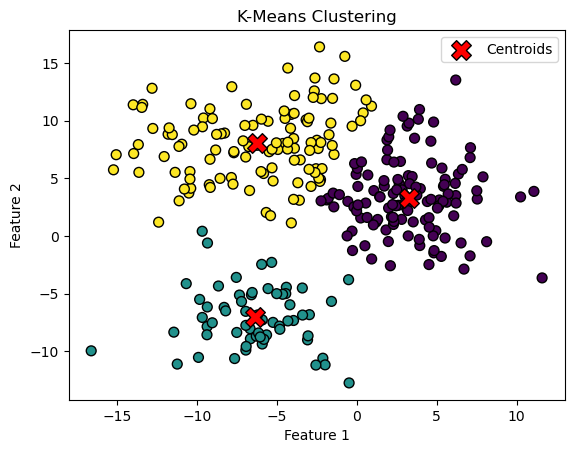

In [13]:

# Apply K-Means algorithm with K=3
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)

# Get the cluster centers and labels
centroids = kmeans.cluster_centers_
labels = kmeans.labels_

# Visualizing the clusters and their centroids
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis', marker='o', edgecolor='black')
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', edgecolors='black', label='Centroids')
plt.title('K-Means Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()


In [14]:
# 计算 Inertia (所有样本到各自中心距离平方之和)
print(f"Inertia: {kmeans.inertia_}")


Inertia: 5950.263339789602


## 小结

在本教程中，我们演示了如何使用Python和Scikit-learn实现K-means聚类算法。我们可视化了数据，应用了K-means，并探索了算法如何将数据点分配到聚类中。K-means是一种简单且高效的聚类方法，但请记住，它需要预先指定聚类的数量。

## 下一步：设计一种可以改变聚类数量的改进版k-means算法

In [16]:
# 循环迭代 - 使用显式导入以避免渲染错误
try:
    import ipywidgets as widgets
    from ipywidgets import interact, IntSlider
except Exception as e:
    print('ipywidgets not available:', e)
    print('Install with: pip install ipywidgets')
    raise
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

def vary_k(n):
    kmeans = KMeans(n_clusters=n, random_state=42)
    kmeans.fit(X)
    centroids = kmeans.cluster_centers_
    labels = kmeans.labels_
    plt.figure(figsize=(6,4))
    plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis', marker='o', edgecolor='black')
    plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', edgecolors='black', label='Centroids')
    plt.title(f'K-Means Clustering (K={n})')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.show()

interact(vary_k, n=IntSlider(value=2, min=2, max=10, step=1, description='聚类簇个数'))

interactive(children=(IntSlider(value=2, description='聚类簇个数', max=10, min=2), Output()), _dom_classes=('widget…

<function __main__.vary_k(n)>

## 思考：如何设计合适的算法，评估决定最优的簇数量？用代码实现你的想法！